# Karachi AQI — Exploratory Data Analysis

This notebook walks through the backfilled hourly dataset before training. Run `python src/pipelines/backfill.py --days 90` first so `data/backfill.csv` is available.

Charts are saved under `notebooks/visuals/`.

In [37]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml
import warnings
from IPython.display import display

warnings.filterwarnings("ignore")
%matplotlib inline

ROOT = Path("..").resolve()
VISUALS = ROOT / "notebooks" / "visuals"
DATA = ROOT / "data" / "backfill.csv"
VISUALS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT))

from src.features.build_features import (
    PM25_CALIBRATION_FACTOR,
    compute_aqi_us,
    get_feature_columns,
    get_target_columns,
    prepare_training_frame,
    preprocess_training_splits,
    WINSORIZE_FEATURE_COLS,
)
from src.models.sklearn_trainer import time_split

with open(ROOT / "config" / "settings.yaml") as f:
    CFG = yaml.safe_load(f)

TEST_DAYS = CFG["data"]["train_test_split_days"]
HORIZONS = CFG["data"]["forecast_horizons_h"]
AQI_BANDS = [
    (50, "Good"),
    (100, "Moderate"),
    (150, "USG"),
    (200, "Unhealthy"),
    (300, "Very Unhealthy"),
]

plt.rcParams.update({"figure.figsize": (14, 4), "axes.grid": True, "font.size": 10})

def savefig(name: str):
    path = VISUALS / name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

## 1. Loading the data and checking quality

Before any plots, I check whether the hourly file is complete enough to trust for modeling.

In [38]:
df = pd.read_csv(DATA, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"Period: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"Duplicate timestamps: {df['timestamp'].duplicated().sum()}")

expected = pd.date_range(df["timestamp"].min(), df["timestamp"].max(), freq="h")
missing_hours = expected.difference(df["timestamp"])
print(f"Missing hourly slots: {len(missing_hours)} ({100 * len(missing_hours) / len(expected):.1f}% of full timeline)")

miss = (df.isnull().mean() * 100).sort_values(ascending=False)
print("\nMissing % (top columns):")
print(miss.head(12).round(2).to_string())

display(df.head(3))

DATASET OVERVIEW
Rows: 936  |  Columns: 31
Period: 2026-02-24 00:00:00 → 2026-05-21 23:00:00
Duplicate timestamps: 0
Missing hourly slots: 1152 (55.2% of full timeline)

Missing % (top columns):
pm2_5               0.0
dispersion_index    0.0
aqi_t_plus_48h      0.0
aqi_t_plus_24h      0.0
aqi_change_rate     0.0
aqi_change_24h      0.0
aqi_change_1h       0.0
aqi_rolling_24h     0.0
aqi_rolling_6h      0.0
aqi_lag_24h         0.0
aqi_lag_1h          0.0
log_pm10            0.0


,pm2_5,pm10,no2,o3,aqi_us,timestamp,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation,...,aqi_lag_1h,aqi_lag_24h,aqi_rolling_6h,aqi_rolling_24h,aqi_change_1h,aqi_change_24h,aqi_change_rate,aqi_t_plus_24h,aqi_t_plus_48h,aqi_t_plus_72h
0,52.540,58.6,46.5,39.0,143.0,2026-02-24 00:00:00,21.6,93,4.6,0.0,...,138.0,135.0,137.666667,130.458333,5.0,8.0,0.014695,113.0,104.0,97.0
1,52.398,61.0,44.4,36.0,142.0,2026-02-24 01:00:00,21.1,95,5.8,0.0,...,143.0,134.0,139.000000,130.791667,-1.0,8.0,0.036206,109.0,101.0,97.0
2,51.404,64.0,40.6,36.0,140.0,2026-02-24 02:00:00,20.6,96,6.8,0.0,...,142.0,129.0,139.333333,131.250000,-2.0,11.0,-0.006988,104.0,97.0,96.0


**Summary:** The backfill covers hourly rows across the date range above with no duplicate timestamps. Gaps on the calendar are expected when the API does not return every day; the important part is that the rows we have are usable and that pollutant and weather columns are filled in.

## 2. How the data is cleaned before training

Quick reference to the same steps the Python pipelines apply.

In [39]:
pipeline_steps = pd.DataFrame([
    ("Ingest", "Hourly air quality and weather merged on timestamp"),
    ("Calibration", f"PM2.5 multiplied by {PM25_CALIBRATION_FACTOR} for local sensor bias"),
    ("AQI label", "US EPA 2024 breakpoints on calibrated PM2.5"),
    ("Features", "Time cycles, lags, rolling means, weather interaction terms"),
    ("Clipping", "Large hour-to-hour AQI jumps are capped before modeling"),
    ("Targets", "Future AQI at +24h, +48h, +72h"),
    ("Train prep", "Winsorize volatile columns, fill gaps, clip AQI to 0–500"),
    ("Split", f"Last {TEST_DAYS} days held out for testing (time order kept)"),
], columns=["Stage", "What happens"])
display(pipeline_steps)

feature_cols = get_feature_columns()
target_cols = get_target_columns()
print(f"\nThe model uses {len(feature_cols)} input columns.")
print("Targets:", ", ".join(target_cols))

,Stage,What happens
0,Ingest,Hourly air quality and weather merged on times...
1,Calibration,PM2.5 multiplied by 1.42 for local sensor bias
2,AQI label,US EPA 2024 breakpoints on calibrated PM2.5
3,Features,"Time cycles, lags, rolling means, weather inte..."
4,Clipping,Large hour-to-hour AQI jumps are capped before...
5,Targets,"Future AQI at +24h, +48h, +72h"
6,Train prep,"Winsorize volatile columns, fill gaps, clip AQ..."
7,Split,Last 14 days held out for testing (time order ...



The model uses 22 input columns.
Targets: aqi_t_plus_24h, aqi_t_plus_48h, aqi_t_plus_72h


**Summary:** Open-Meteo data is calibrated, turned into features, then used for training. PM2.5 is not a direct model input because it overlaps heavily with AQI and the lag columns.

## 3. Effect of the 1.42× PM2.5 calibration

Karachi readings from satellite-style sources often run low; we scale PM2.5 before computing AQI.

Average AQI increase after calibration: 20.8
Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\01_calibration_impact.png


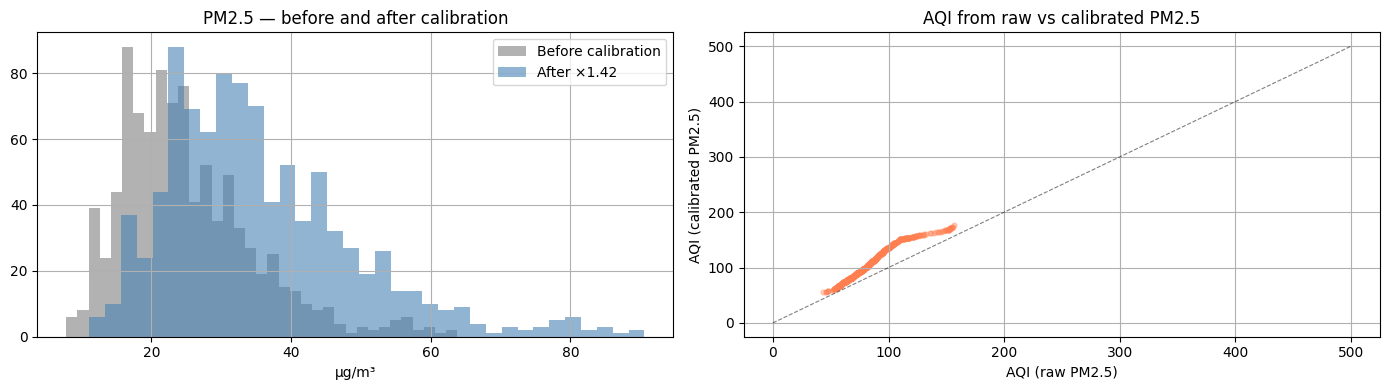

In [40]:
raw_pm = df["pm2_5"] / PM25_CALIBRATION_FACTOR
cal_pm = raw_pm * PM25_CALIBRATION_FACTOR
aqi_raw = compute_aqi_us(raw_pm)
aqi_cal = compute_aqi_us(cal_pm)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(raw_pm.dropna(), bins=35, alpha=0.6, label="Before calibration", color="gray")
axes[0].hist(cal_pm.dropna(), bins=35, alpha=0.6, label=f"After ×{PM25_CALIBRATION_FACTOR}", color="steelblue")
axes[0].set_title("PM2.5 — before and after calibration")
axes[0].set_xlabel("µg/m³")
axes[0].legend()

axes[1].scatter(aqi_raw, aqi_cal, alpha=0.35, s=12, c="coral")
axes[1].plot([0, 500], [0, 500], "k--", lw=0.8, alpha=0.5)
axes[1].set_title("AQI from raw vs calibrated PM2.5")
axes[1].set_xlabel("AQI (raw PM2.5)")
axes[1].set_ylabel("AQI (calibrated PM2.5)")
shift = (aqi_cal - aqi_raw).mean()
print(f"Average AQI increase after calibration: {shift:.1f}")
savefig("01_calibration_impact.png")
plt.show()

**Summary:** Calibration raises PM2.5 and pushes AQI upward on average. Training and the app should use one consistent calibrated AQI, not the raw API value alone.

## 4. Missing values and forecast targets

Recent hours may lack future AQI labels—that is expected until those hours actually occur.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\02_missingness.png


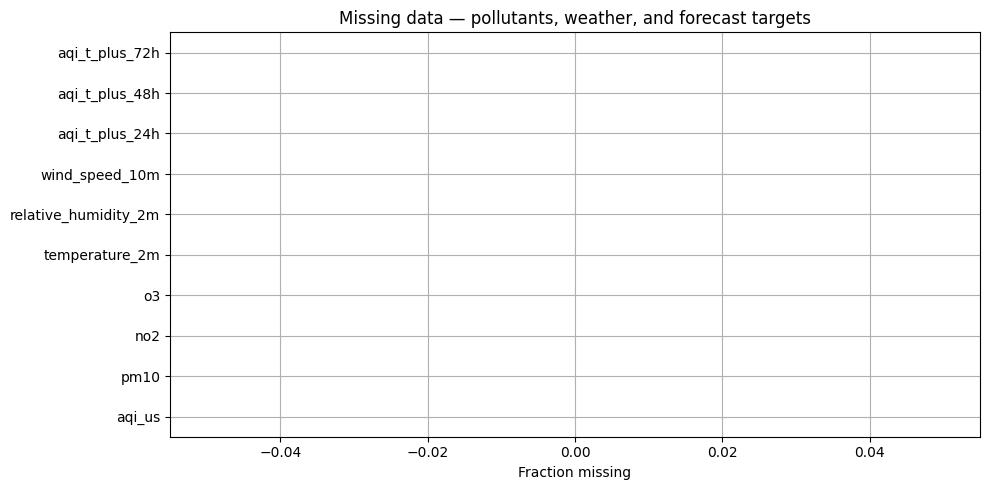

Rows ready for training (features + all targets present): 936 / 936


In [41]:
key_cols = ["aqi_us", "pm10", "no2", "o3", "temperature_2m", "relative_humidity_2m", "wind_speed_10m"] + target_cols
key_cols = [c for c in key_cols if c in df.columns]
miss_key = df[key_cols].isnull().mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
miss_key.plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("Fraction missing")
ax.set_title("Missing data — pollutants, weather, and forecast targets")
savefig("02_missingness.png")
plt.show()

train_ready = prepare_training_frame(df)
print(f"Rows ready for training (features + all targets present): {len(train_ready):,} / {len(df):,}")

**Summary:** Pollutant and weather fields are mostly complete in this CSV. After rebuilding features and keeping only rows with full +24h/+48h/+72h targets, the training count is printed above. Live MongoDB rows at the very end often have null targets until time passes—that is normal.

## 5. Outliers and winsorization on the training split

Extreme spikes in change-rate and pollutant columns are trimmed using train-set percentiles, not deleted.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\03_winsorization_before_after.png


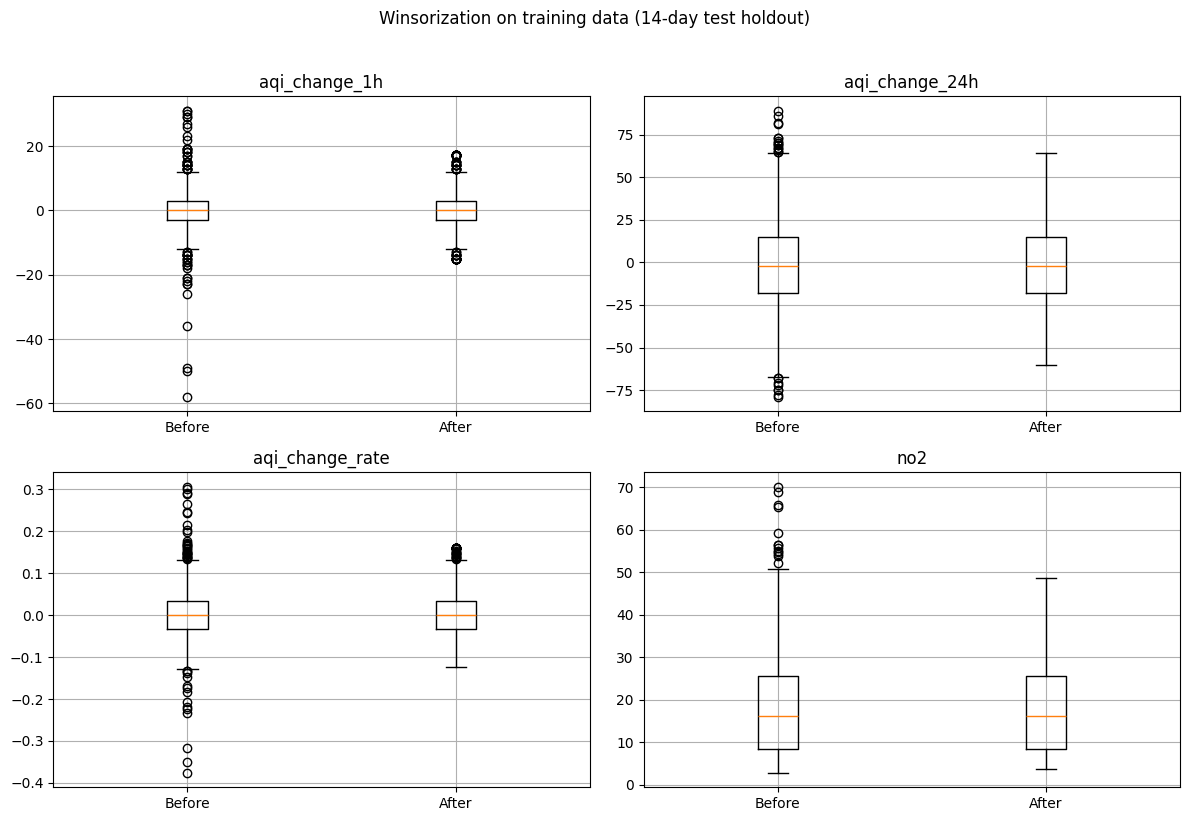

Train: 792 rows  |  Test: 144 rows
Test window: 2026-05-12 00:00:00 → 2026-05-21 23:00:00


In [42]:
full_train = prepare_training_frame(df)
train, test = time_split(full_train, test_days=TEST_DAYS)
train_clean, _ = preprocess_training_splits(train, test, feature_cols, target_cols)

compare_cols = [c for c in WINSORIZE_FEATURE_COLS if c in train.columns][:4]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(compare_cols):
    axes.ravel()[i].boxplot([train[col].dropna(), train_clean[col].dropna()], labels=["Before", "After"])
    axes.ravel()[i].set_title(col)
fig.suptitle(f"Winsorization on training data ({TEST_DAYS}-day test holdout)", y=1.02)
savefig("03_winsorization_before_after.png")
plt.show()

print(f"Train: {len(train):,} rows  |  Test: {len(test):,} rows")
print(f"Test window: {test['timestamp'].min()} → {test['timestamp'].max()}")

**Summary:** Winsorization shortens the whiskers on volatile columns without shifting the median much. We keep the rows and only damp extreme values, which helps linear models in particular.

## 6. AQI over time

Long view of air quality across the backfill period.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\04_aqi_timeseries.png


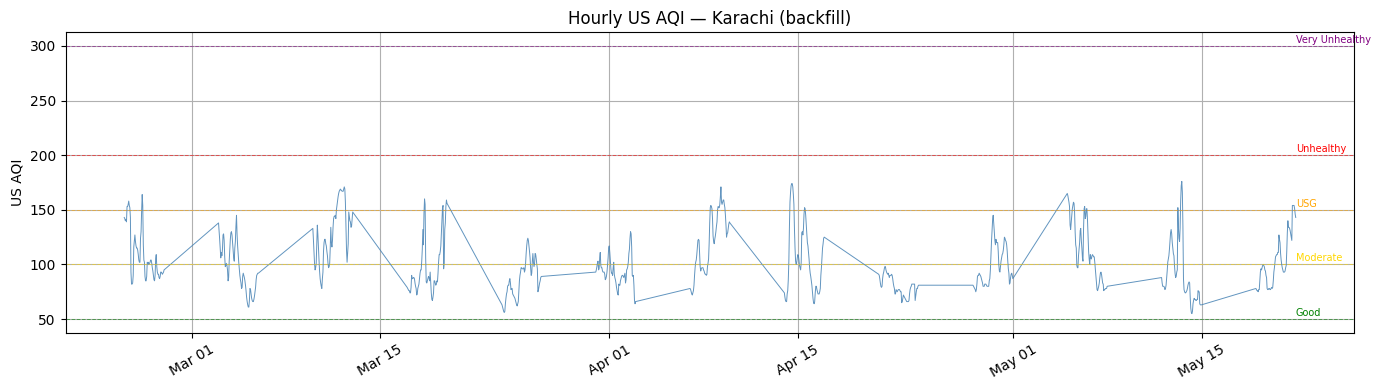

Median AQI: 95


In [43]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["timestamp"], df["aqi_us"], lw=0.7, color="steelblue", alpha=0.85)
colors = ["green", "gold", "orange", "red", "purple", "maroon"]
for (thr, label), color in zip(AQI_BANDS, colors):
    ax.axhline(thr, ls="--", lw=0.7, alpha=0.55, color=color)
    ax.text(df["timestamp"].max(), thr + 3, label, fontsize=7, color=color)
ax.set_title("Hourly US AQI — Karachi (backfill)")
ax.set_ylabel("US AQI")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
savefig("04_aqi_timeseries.png")
plt.show()

print(f"Median AQI: {df['aqi_us'].median():.0f}")

**Summary:** AQI moves up and down over the backfill window rather than staying flat. Many hours sit in Moderate or worse bands, so there is enough variation for the model to learn from.

## 7. How often each AQI category appears

Distribution of hourly readings against standard EPA bands.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\05_aqi_distribution.png


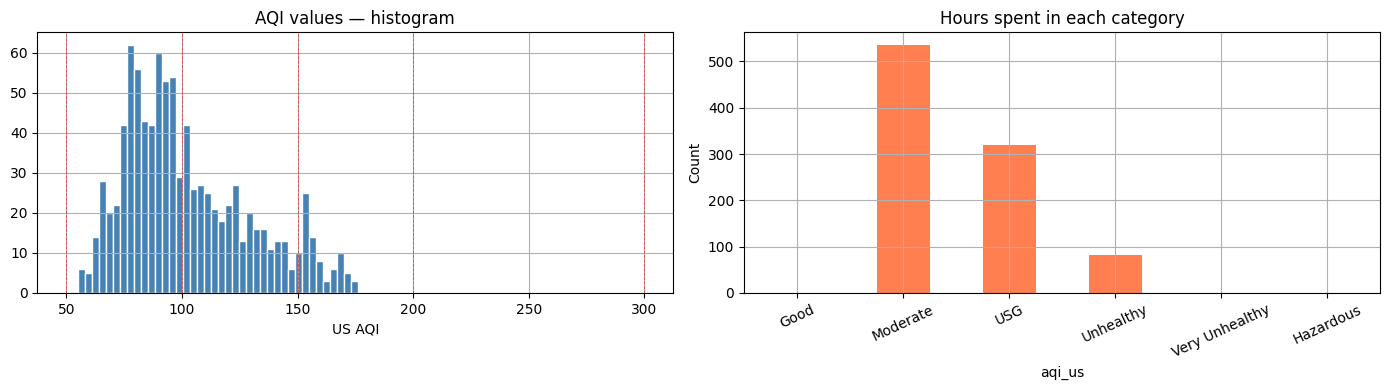

aqi_us
Good                0.0
Moderate          536.0
USG               319.0
Unhealthy          81.0
Very Unhealthy      0.0
Hazardous           0.0


In [44]:
def aqi_category(aqi):
    if aqi <= 50: return "Good"
    if aqi <= 100: return "Moderate"
    if aqi <= 150: return "USG"
    if aqi <= 200: return "Unhealthy"
    if aqi <= 300: return "Very Unhealthy"
    return "Hazardous"

cats = df["aqi_us"].apply(aqi_category)
order = ["Good", "Moderate", "USG", "Unhealthy", "Very Unhealthy", "Hazardous"]
cat_counts = cats.value_counts().reindex(order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["aqi_us"].dropna(), bins=40, color="steelblue", edgecolor="white")
for thr, _ in AQI_BANDS:
    axes[0].axvline(thr, color="red", ls="--", lw=0.6, alpha=0.6)
axes[0].set_title("AQI values — histogram")
axes[0].set_xlabel("US AQI")

cat_counts.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Hours spent in each category")
axes[1].set_ylabel("Count")
plt.xticks(rotation=25)
savefig("05_aqi_distribution.png")
plt.show()

print(cat_counts.to_string())

**Summary:** Most hours fall in Moderate or higher categories. Karachi does not spend most of its time in the Good band, which matches what we expect from local air quality.

## 8. Patterns by hour and month

Diurnal cycle and seasonal tendency in the backfill window.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\06_hourly_monthly_pattern.png


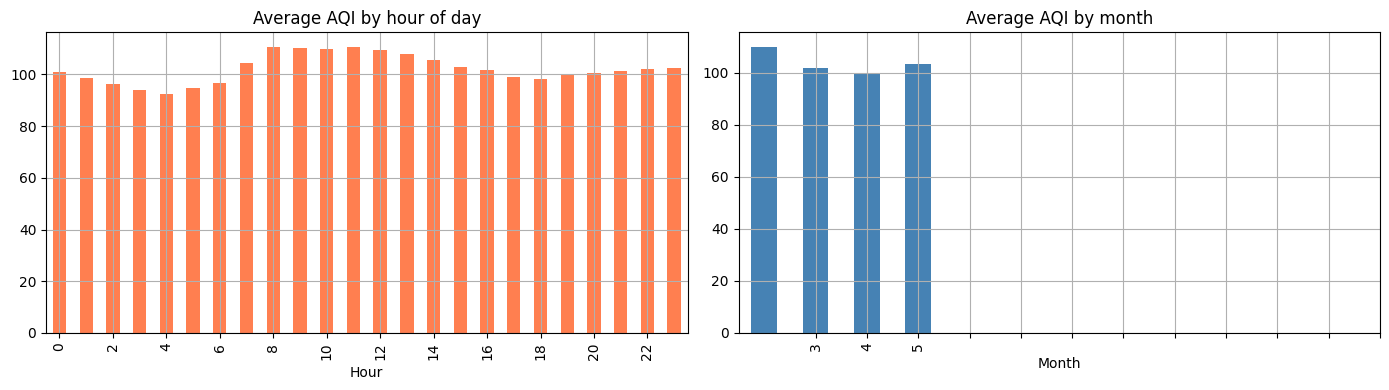

In [45]:
hour = df["timestamp"].dt.hour
month = df["timestamp"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby(hour)["aqi_us"].mean().plot(kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Average AQI by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_xticks(range(0, 24, 2))

df.groupby(month)["aqi_us"].mean().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Average AQI by month")
axes[1].set_xlabel("Month")
axes[1].set_xticks(range(1, 13))
savefig("06_hourly_monthly_pattern.png")
plt.show()

**Summary:** AQI is not uniform across the day or across months. Some hours and cooler months look worse on average, which is why cyclic time features are included in the model.

## 9. Correlations between inputs

Which columns move together—and which would duplicate each other in a linear model.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\07_correlation.png


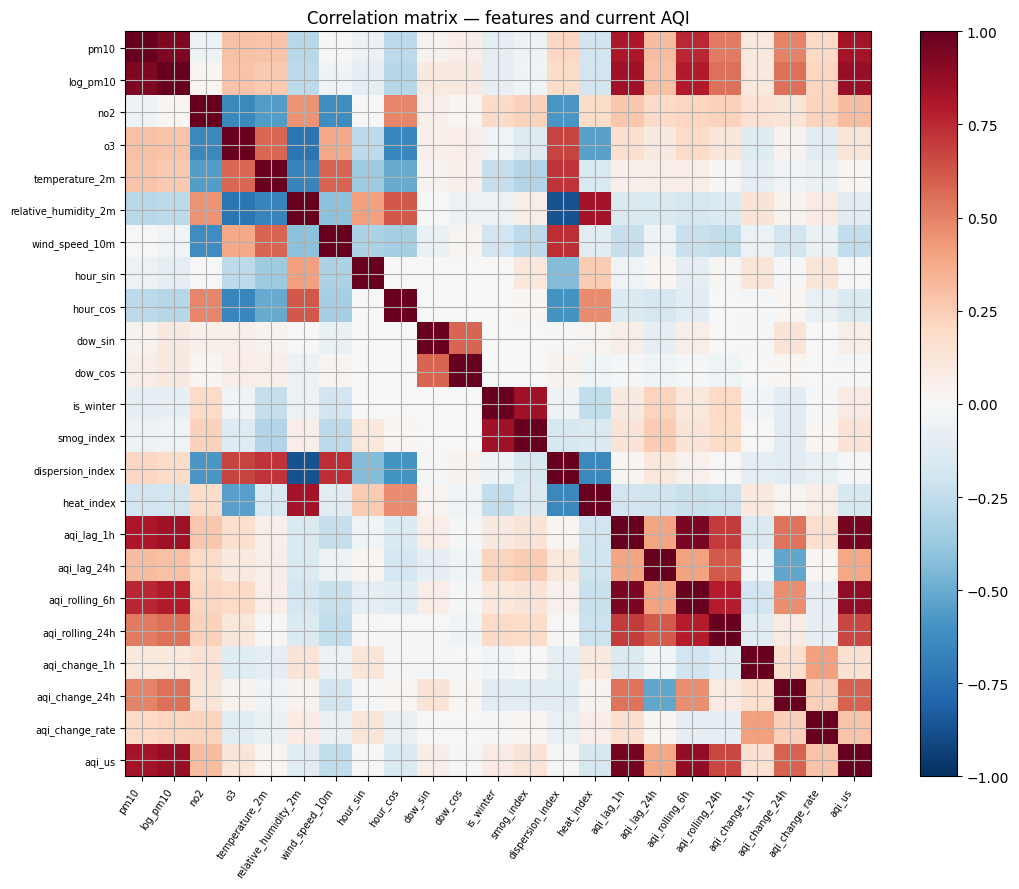

In [46]:
corr_cols = [c for c in feature_cols + ["aqi_us"] if c in full_train.columns]
corr = full_train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=55, ha="right", fontsize=7)
ax.set_yticklabels(corr_cols, fontsize=7)
ax.set_title("Correlation matrix — features and current AQI")
savefig("07_correlation.png")
plt.show()

**Summary:** AQI and its lag or rolling columns cluster together because they come from the same series. Weather columns are more separate. That supports leaving raw PM2.5 out of the feature set.

## 10. Forecast targets at 24h, 48h, and 72h

What the model is asked to predict, and how it relates to yesterday's AQI.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\08_target_distributions.png


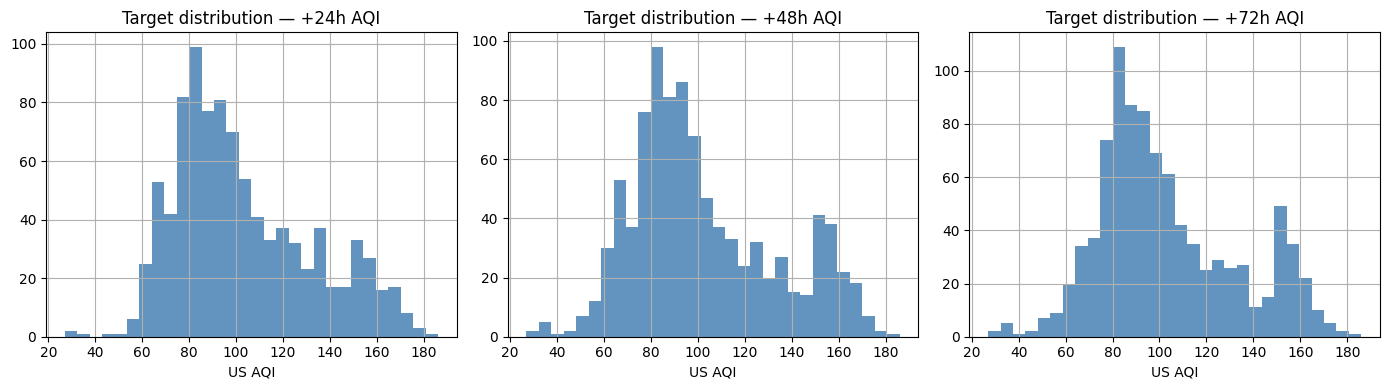

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\09_lag_vs_target_24h.png


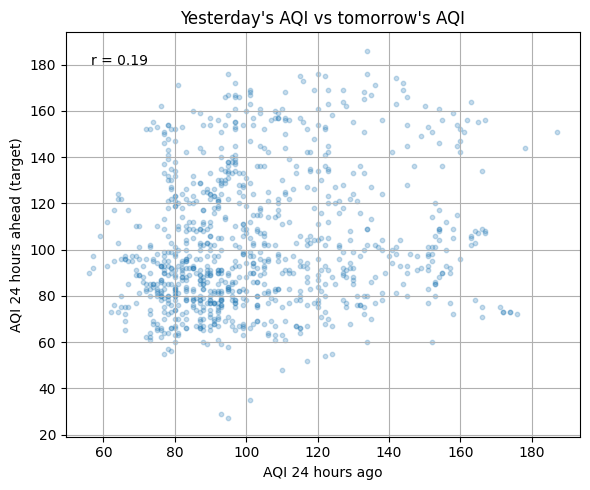

Correlation (lag-24h vs +24h target): 0.19


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, h in zip(axes, HORIZONS):
    col = f"aqi_t_plus_{h}h"
    if col in full_train.columns:
        full_train[col].dropna().hist(bins=30, ax=ax, color="steelblue", alpha=0.85)
    ax.set_title(f"Target distribution — +{h}h AQI")
    ax.set_xlabel("US AQI")
savefig("08_target_distributions.png")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
r24 = np.nan
if "aqi_lag_24h" in full_train.columns and "aqi_t_plus_24h" in full_train.columns:
    sub = full_train[["aqi_lag_24h", "aqi_t_plus_24h"]].dropna()
    ax.scatter(sub["aqi_lag_24h"], sub["aqi_t_plus_24h"], alpha=0.25, s=10)
    ax.set_xlabel("AQI 24 hours ago")
    ax.set_ylabel("AQI 24 hours ahead (target)")
    ax.set_title("Yesterday's AQI vs tomorrow's AQI")
    r24 = sub["aqi_lag_24h"].corr(sub["aqi_t_plus_24h"])
    ax.text(0.05, 0.92, f"r = {r24:.2f}", transform=ax.transAxes)
savefig("09_lag_vs_target_24h.png")
plt.show()

print(f"Correlation (lag-24h vs +24h target): {r24:.2f}")

**Summary:** The three target distributions look similar and stay skewed toward moderate and poor air. Lag-24h and the +24h target are positively correlated, so persistence matters. Longer horizons are usually harder to predict.

## 11. Train and test split

We hold out the most recent days so the model is scored on future-like data, not random rows.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\10_train_test_split.png


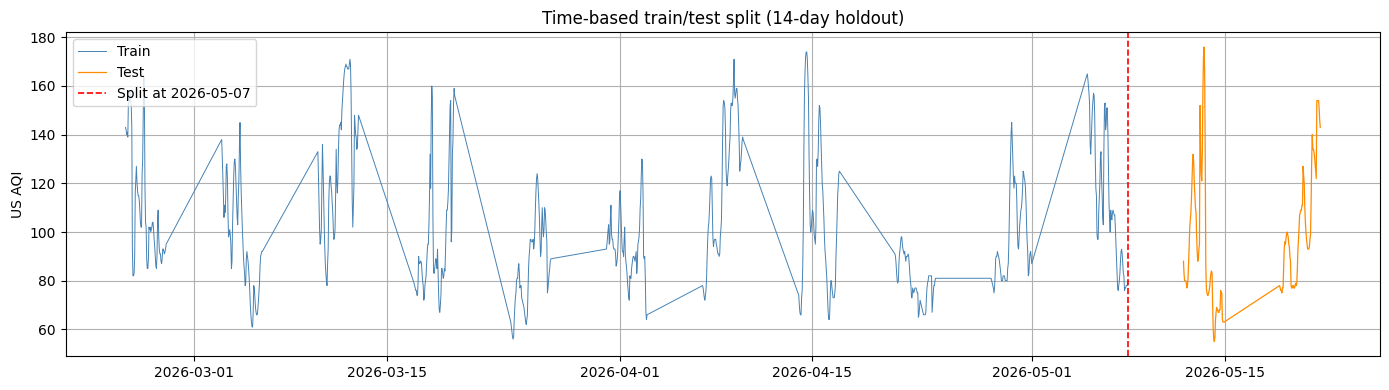

In [48]:
cutoff = train["timestamp"].max()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train["timestamp"], train["aqi_us"], label="Train", color="steelblue", lw=0.7)
ax.plot(test["timestamp"], test["aqi_us"], label="Test", color="darkorange", lw=0.9)
ax.axvline(cutoff, color="red", ls="--", lw=1.2, label=f"Split at {cutoff.date()}")
ax.set_title(f"Time-based train/test split ({TEST_DAYS}-day holdout)")
ax.set_ylabel("US AQI")
ax.legend()
savefig("10_train_test_split.png")
plt.show()

**Summary:** Training uses older hours; testing uses only the last 14 days (or whatever `train_test_split_days` is set to in config). The model never sees test-period rows during fitting.

## 12. Which features track the +24h target best

Simple linear association—not final importance, but a sanity check.

Saved → C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals\11_feature_target_assoc_24h.png


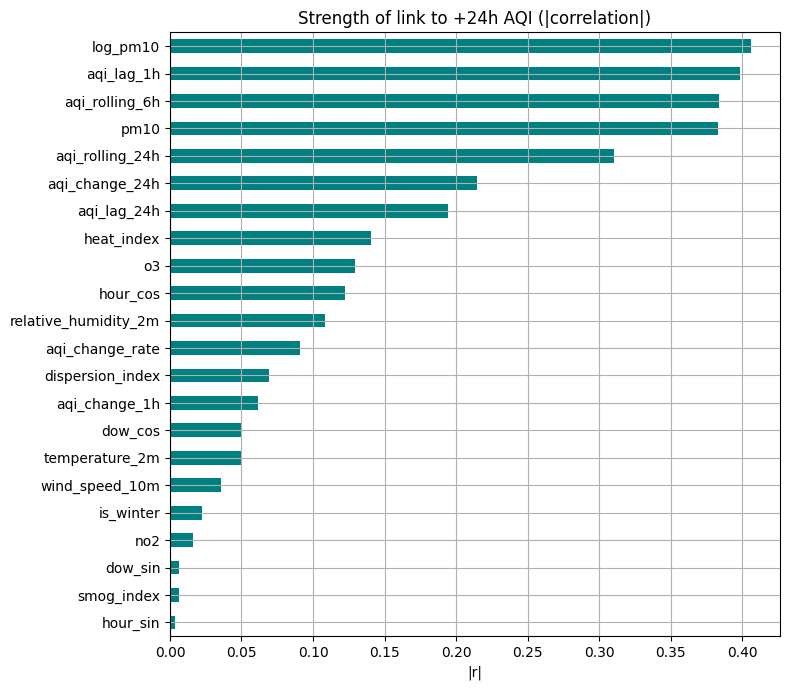

Strongest links:
aqi_rolling_24h    0.310536
pm10               0.383185
aqi_rolling_6h     0.383567
aqi_lag_1h         0.398572
log_pm10           0.406194


In [50]:
target_24 = "aqi_t_plus_24h"
if target_24 in full_train.columns:
    assoc = full_train[feature_cols + [target_24]].corr()[target_24].drop(target_24).abs().sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 7))
    assoc.plot(kind="barh", ax=ax, color="teal")
    ax.set_title("Strength of link to +24h AQI (|correlation|)")
    ax.set_xlabel("|r|")
    savefig("11_feature_target_assoc_24h.png")
plt.show()
print("Strongest links:")
print(assoc.tail(5).to_string())

**Summary:** AQI-based lags and rolling means show the strongest link to the +24h target in this view. Weather-only columns are weaker on their own, which fits the idea that tomorrow's AQI depends mostly on recent air quality with weather as a modifier.

## 13. Closing notes

All figures for this run are in `notebooks/visuals/`. Re-run the notebook after a new backfill if `data/backfill.csv` changes.

In [51]:
saved = sorted(VISUALS.glob("*.png"))
print(f"{len(saved)} PNG files in {VISUALS}:")
for p in saved:
    print(f"  - {p.name}")

11 PNG files in C:\Users\USER\Desktop\AQI Predictor\notebooks\visuals:
  - 01_calibration_impact.png
  - 02_missingness.png
  - 03_winsorization_before_after.png
  - 04_aqi_timeseries.png
  - 05_aqi_distribution.png
  - 06_hourly_monthly_pattern.png
  - 07_correlation.png
  - 08_target_distributions.png
  - 09_lag_vs_target_24h.png
  - 10_train_test_split.png
  - 11_feature_target_assoc_24h.png
